In [20]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import Legendre
# ============================================================
# 1. PARÂMETROS DO PROBLEMA
# ============================================================
a = 1.0
# velocidade de advecção
kx = 2 * np.pi
# número de onda inicial
xmin, xmax = 0.0, 1.0
# domínio




# ============================================================
# 2. FUNÇÕES AUXILIARES (GLL, derivação, pesos)
# ============================================================
def gauss_lobatto_nodes(N):
    if N == 1:
        return np.array([-1.0, 1.0])
    x = -np.cos(np.pi * np.arange(N + 1) / N)
    P = Legendre.basis(N)
    dP = P.deriv()
    d2P = dP.deriv()
    for _ in range(100):
        x_old = x.copy()
        x = x_old - dP(x) / d2P(x)
        x[0], x[-1] = -1.0, 1.0
        if np.max(np.abs(x - x_old)) < 1e-15:
            break
        
    return x


def differentiation_matrix(xi):
    """Matriz de diferenciação baricêntrica (estável)."""
    N = len(xi) - 1
    w = np.ones(N + 1)
    
    for j in range(N + 1):
        for i in range(N + 1):
            if i != j:
                w[j] *= 1.0 / (xi[j] - xi[i])
    D = np.zeros((N + 1, N + 1))
    
    for i in range(N + 1):
        for j in range(N + 1):
            if i != j:
                D[i, j] = (w[j] / w[i]) / (xi[i] - xi[j])
        D[i, i] = -np.sum(D[i, :])
        
    return D

def gll_weights(xi, N):
    if N == 1:
        return np.array([1.0, 1.0])
    P = Legendre.basis(N)
    w = np.zeros(N + 1)
    for i in range(N + 1):
        w[i] = 2.0 / (N * (N + 1) * P(xi[i])**2)
    return w

def numerical_flux(uL, uR, a, flux_type):
    if flux_type == 'central': 
        return 0.5 * a * (uL + uR)
    elif flux_type == 'upwind':
        return a * uL if a > 0 else a * uR
    else:
        raise ValueError("flux_type inválido")
    
# ============================================================
# 3. CONSTRUÇÃO DO OPERADOR DG (por elemento)
# ============================================================
def build_dg_operator(K, N, a, flux_type):
    dx_elem = (xmax - xmin) / K
    xi = gauss_lobatto_nodes(N)
    D_ref = differentiation_matrix(xi)# no elemento de referência [-1,1]
    D_phys = (2.0 / dx_elem) * D_ref# escala física
    w = gll_weights(xi, N)
    M_local = w * dx_elem / 2.0
    # massa diagonal de cada nó (mass lumping)
    
    # Coordenadas físicas dos nós
    x_nodes = np.zeros((K, N + 1))
    for k in range(K):
        xL = xmin + k * dx_elem
        x_nodes[k, :] = xL + 0.5 * (xi + 1) * dx_elem
        
    return {
        'K': K, 'N': N, 'dx_elem': dx_elem,
        'D_phys': D_phys, 'M_local': M_local,
        'x_nodes': x_nodes, 'a': a, 'flux_type': flux_type
        }
    
    
# ============================================================
# 4. LADO DIREITO (RHS) – FORMA FORTE CORRETA
# ============================================================
def rhs(u_flat, op):
    K, N = op['K'], op['N']
    D = op['D_phys']
    M = op['M_local']
    a = op['a']
    flux_type = op['flux_type']
    
    u = u_flat.reshape((K, N + 1))
    du = np.zeros_like(u)
    
    for k in range(K):
        # Termo volumétrico: -a * D_phys @ u (forma forte)
        du[k, :] = -a * (D @ u[k, :])
        # Interface direita (x_R) – n = +1
        uL = u[k, N]
        # valor à esquerda da interface
        uR = u[(k + 1) % K, 0]
        # valor à direita
        fstar_R = numerical_flux(uL, uR, a, flux_type)
        # contribuição no último nó do elemento k
        du[k, N] += a * (uL - fstar_R / a) / M[N] # fstar_R / a = u^*
        
        # Interface esquerda (x_L) – n = -1
        uL_prev = u[(k - 1) % K, N]
        uR_curr = u[k, 0]
        # valor à esquerda (vem do elemento k-1)
        # valor à direita (elemento k)
        fstar_L = numerical_flux(uL_prev, uR_curr, a, flux_type)
        du[k, 0] += a * (-uR_curr + fstar_L / a) / M[0] # note o sinal
        
    return du.flatten()

# ============================================================
# 5. INTEGRADOR TEMPORAL (LSRK4 de 5 estágios)
# ============================================================
def lsrk4_step(u, rhs_func, dt, op):
    A = np.array([0.0,
    -567301805773.0 / 1357537059087.0,
    -2404267990393.0 / 2016746695238.0,
    -3550918686646.0 / 2091501179385.0,
    -1275806237668.0 / 842570457699.0])
    
    B = np.array([1432997174477.0 / 9575080441755.0,
    5161836677717.0 / 13612068292357.0,
    1720146321549.0 / 2090206949498.0,
    3134564353537.0 / 4481467310338.0,
    2277821191437.0 / 14882151754819.0])
    
    q = np.zeros_like(u)
    for i in range(5):
        k = rhs_func(u, op)
        q = A[i] * q + dt * k
        u = u + B[i] * q
    return u

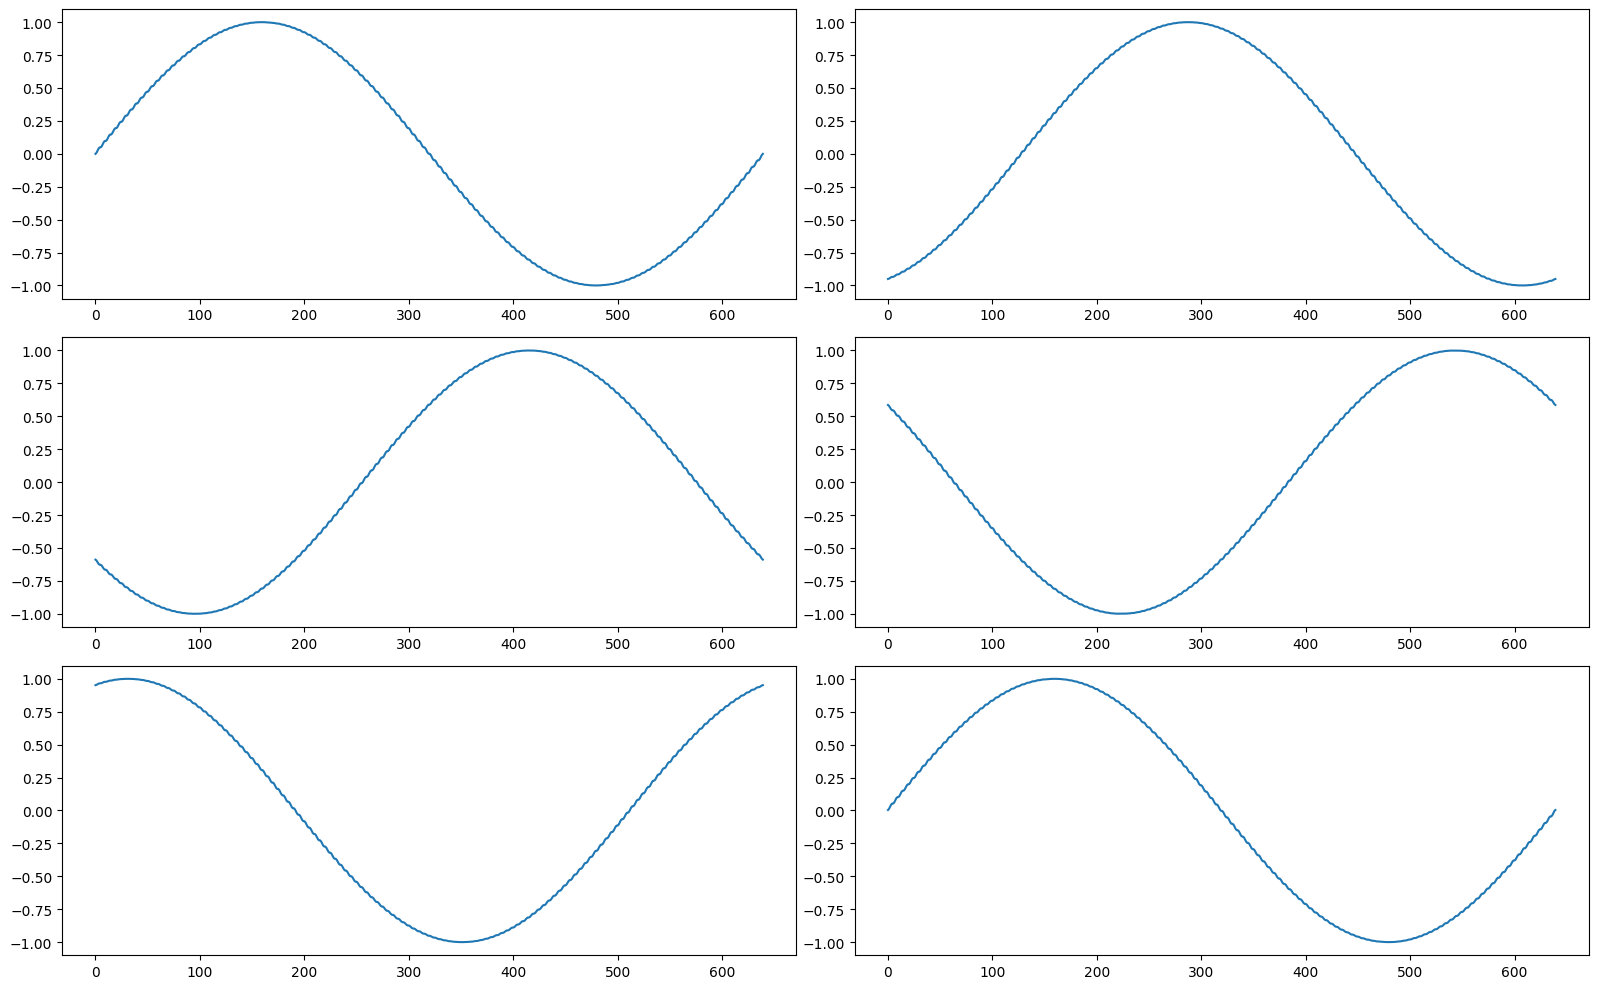

In [21]:
# ============================================================
# 6. SIMULAÇÃO COMPLETA
# ============================================================
def run_simulation(K, N, CFL, T_final, a, kx, flux_type):
    op = build_dg_operator(K, N, a, flux_type)
    x_nodes = op['x_nodes']
    
    # Condição inicial
    u = np.sin(kx * x_nodes).flatten().copy()
    # Passo de tempo: CFL ~ 0.1 para N>1, ~0.5 para N=1
    dx = op['dx_elem']
    dt = CFL * dx / (a * (N + 1) ** 2) # critério para DG explícito
    n_steps = max(1, int(T_final / dt))
    dt = T_final / n_steps
    
    u_history = []
    steps_list = np.linspace(0, n_steps - 10, 6)
    
    for step in range(n_steps):
        u = lsrk4_step(u, rhs, dt, op)
        if step in steps_list:
            u_history.append(u)
        
    return u.reshape((K, N + 1)), x_nodes, u_history

u, nodes, u_history = run_simulation(128, 4, 0.2, 1, a, kx, 'central')

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    ax.plot(u_history[i].flatten())

plt.tight_layout()
plt.show()